## Homework 2: Models for Regression

#### Air Quality Prediction (NO2)

#### **Objetivo:** Desenvolver modelos de regressão para calibrar sensores de baixo custo e prever a concentração de Dióxido de Nitrogênio (NO₂).

### 1. Configurações Iniciais

#### 1.1 Importando Bibliotecas

In [2]:
from sklearn.linear_model import LinearRegression
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import zscore

#### 1.2 Configurações visuais e diretório para salvar imagens

In [3]:
# Configurações Visuais
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6)})

# Diretório para salvar imagens
PATH_FIG = "./figures_hw2"
os.makedirs(PATH_FIG, exist_ok=True)

def savefig(name): return plt.savefig(os.path.join(
    PATH_FIG, f"{name}.png"), bbox_inches="tight")

#### 1.3 Loading e limpeza inicial

In [4]:
# Loading Dataset
data_path = "../database/air_quality_uci.csv"
air_quality = pd.read_csv(data_path, sep=";", decimal=",", na_values=-200)

# Limpeza inicial dos dados
air_quality = air_quality.iloc[:, :-2]  # Remove colunas vazias
air_quality.dropna(inplace=True)        # Remove linhas com NaN

print(f"Dataset Carregado: {air_quality.shape}")

Dataset Carregado: (827, 15)


#### 1.4 Temporal e outliers

=== Tabela de Estatística Descritiva ===


,count,mean,std,min,25%,50%,75%,max
CO(GT),827.0,2.35,1.41,0.3,1.30,2.00,3.10,8.10
PT08.S1(CO),827.0,1207.88,241.82,753.0,1017.00,1172.00,1380.00,2040.00
NMHC(GT),827.0,231.03,208.46,7.0,77.00,157.00,318.50,1189.00
C6H6(GT),827.0,10.77,7.42,0.5,4.80,9.10,14.80,39.20
PT08.S2(NMHC),827.0,966.12,266.42,448.0,754.00,944.00,1142.50,1754.00
NOx(GT),827.0,143.50,81.83,12.0,81.00,128.00,187.00,478.00
PT08.S3(NOx),827.0,963.30,265.91,461.0,769.00,920.00,1131.00,1935.00
NO2(GT),827.0,100.26,31.49,19.0,78.50,99.00,122.00,196.00
PT08.S4(NO2),827.0,1600.62,302.29,955.0,1369.50,1556.00,1783.50,2679.00
PT08.S5(O3),827.0,1045.81,400.13,263.0,760.00,1009.00,1320.00,2359.00


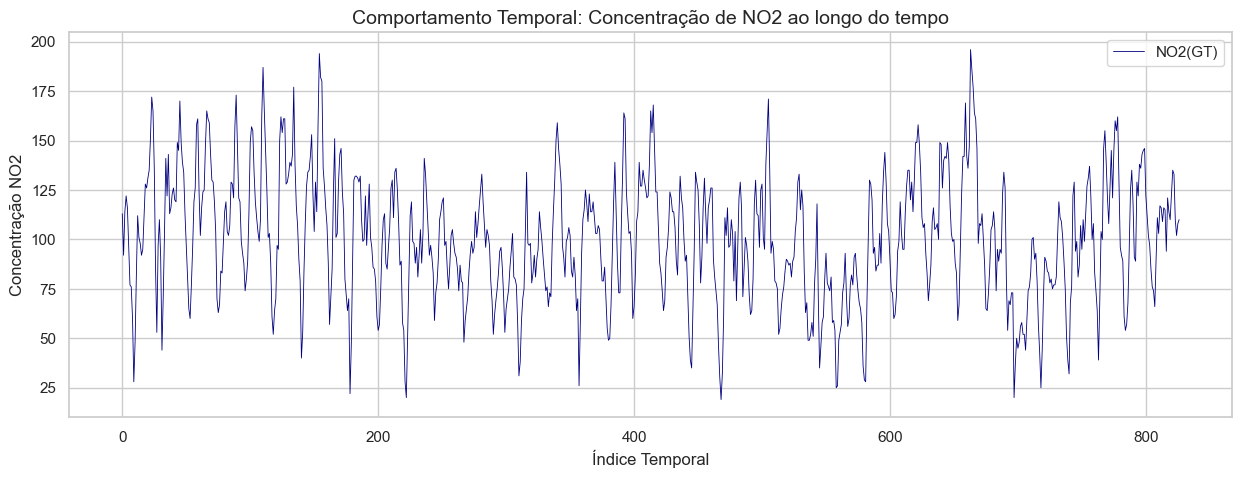

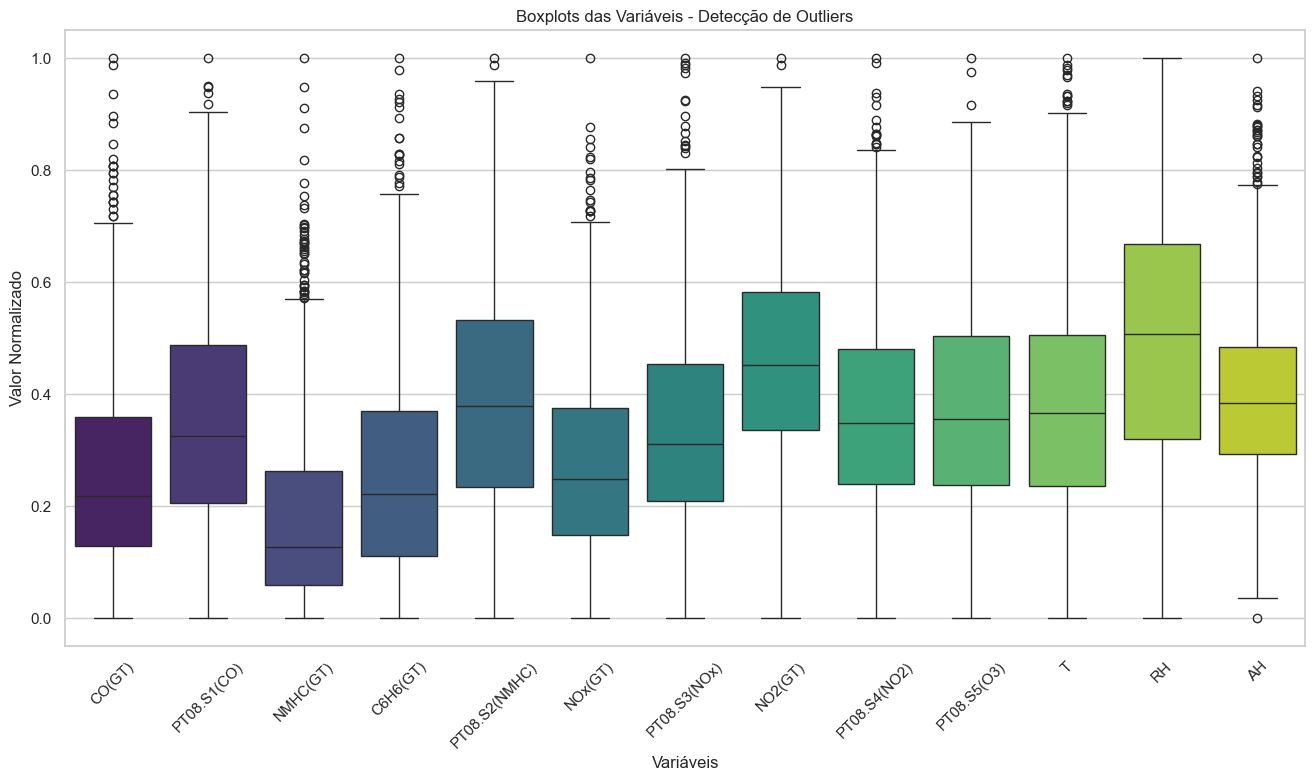

In [5]:
print("=== Tabela de Estatística Descritiva ===")
display(air_quality.describe().T.round(2))

# Comportamento Temporal (Target NO2)
plt.figure(figsize=(15, 5))
if not np.issubdtype(air_quality.index.dtype, np.datetime64):
    x_axis = range(len(air_quality))
else:
    x_axis = air_quality.index

plt.plot(x_axis, air_quality["NO2(GT)"],
         label="NO2(GT)", color='navy', linewidth=0.6)
plt.title(
    "Comportamento Temporal: Concentração de NO2 ao longo do tempo", fontsize=14)
plt.xlabel("Índice Temporal")
plt.ylabel("Concentração NO2")
plt.legend()
savefig("eda_temporal_behavior")
plt.show()

# Boxplots e Análise de Outliers
# Seleciona apenas colunas numéricas
df_numeric = air_quality.select_dtypes(include=[np.number])

# Normalização Min-Max para visualização
df_norm_viz = (df_numeric - df_numeric.min()) / \
    (df_numeric.max() - df_numeric.min())

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_norm_viz, palette="viridis")
plt.xticks(rotation=45)
plt.title("Boxplots das Variáveis - Detecção de Outliers")
plt.xlabel("Variáveis")
plt.ylabel("Valor Normalizado")
savefig("eda_boxplots_outliers")
plt.show()

### 2. Definição de Variáveis e Split
##### Definimos `NO2(GT)` como nossa variável alvo ($Y$). As demais variáveis numéricas (sensores e clima) serão os preditores ($X$).

#### 2.1 Separação X e Y

In [6]:
TARGET_COL = "NO2(GT)"

# Seleção de colunas para preditores
numeric_cols = air_quality.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != TARGET_COL]
X = air_quality[feature_cols]
y = air_quality[TARGET_COL]

print(f"Target: {TARGET_COL}")
print(f"Preditores ({len(feature_cols)}): {feature_cols}")

Target: NO2(GT)
Preditores (12): ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


#### 2.2 Divisão Treino e Teste
##### Realizamos a divisão 75/25 **antes** de qualquer normalização para evitar *Data Leakage*.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste:  {X_test.shape}")

Treino: (620, 12)
Teste:  (207, 12)


###  3. Pré-processamento

#### 3.1 Skewness e Normalização
##### Aplicamos transformação Logarítmica nas variáveis assimétricas e Normalização Z-Score.
##### Calculamos os parâmetros (média, desvio) apenas no Treino e aplicamos no Teste.

In [8]:
def process_data(X_train_raw, X_test_raw):
    X_tr = X_train_raw.copy()
    X_ts = X_test_raw.copy()  # Copia para não alterar original

    # Tratamento de Skewness (Log1p)
    skewness = X_tr.skew()
    high_skew_cols = skewness[abs(skewness) > 0.75].index

    print(
        f"Colunas com alta assimetria (Log transform): {list(high_skew_cols)}")

    for col in high_skew_cols:
        min_val = min(X_tr[col].min(), X_ts[col].min())
        offset = 0
        if min_val <= 0:
            offset = abs(min_val) + 1

        X_tr[col] = np.log1p(X_tr[col] + offset)
        X_ts[col] = np.log1p(X_ts[col] + offset)

    # Normalização Z-Score (Fit no Train, Transform no Test)
    train_mean = X_tr.mean()
    train_std = X_tr.std()

    X_tr_norm = (X_tr - train_mean) / train_std
    X_ts_norm = (X_ts - train_mean) / train_std

    return X_tr_norm, X_ts_norm

# Aplica a função
X_train_norm, X_test_norm = process_data(X_train, X_test)

Colunas com alta assimetria (Log transform): ['CO(GT)', 'NMHC(GT)', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)']


### 3.2 Visualização do Impacto do Pré-processamento
##### Comparamos a distribuição original vs. transformada de uma variável crítica.

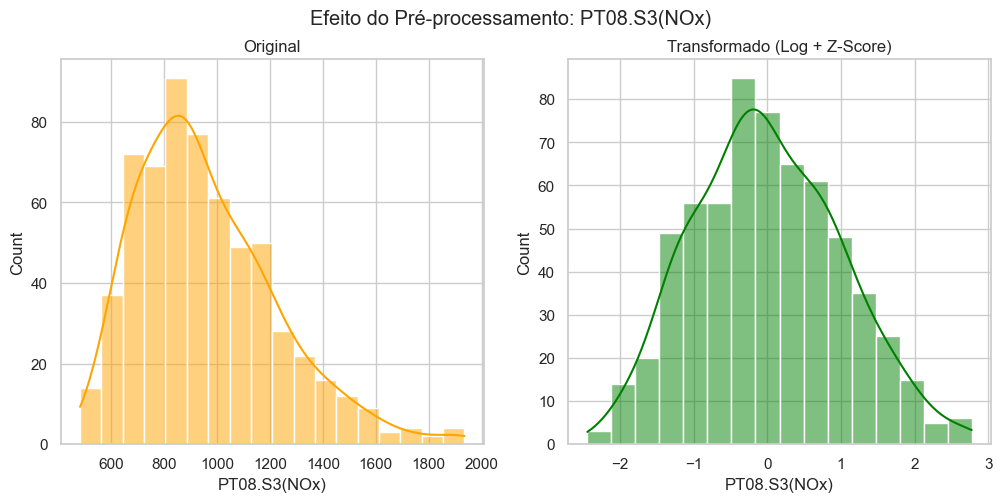

In [9]:
col_check = "PT08.S3(NOx)"  # Exemplo de variável geralmente assimétrica

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X_train[col_check], kde=True, ax=ax[0],
             color="orange").set_title("Original")
sns.histplot(X_train_norm[col_check], kde=True, ax=ax[1],
             color="green").set_title("Transformado (Log + Z-Score)")
plt.suptitle(f"Efeito do Pré-processamento: {col_check}")
plt.show()

### 4. Análise de Correlação e Linearidade
#### Verificamos a correlação linear entre os preditores processados e o alvo NO2.

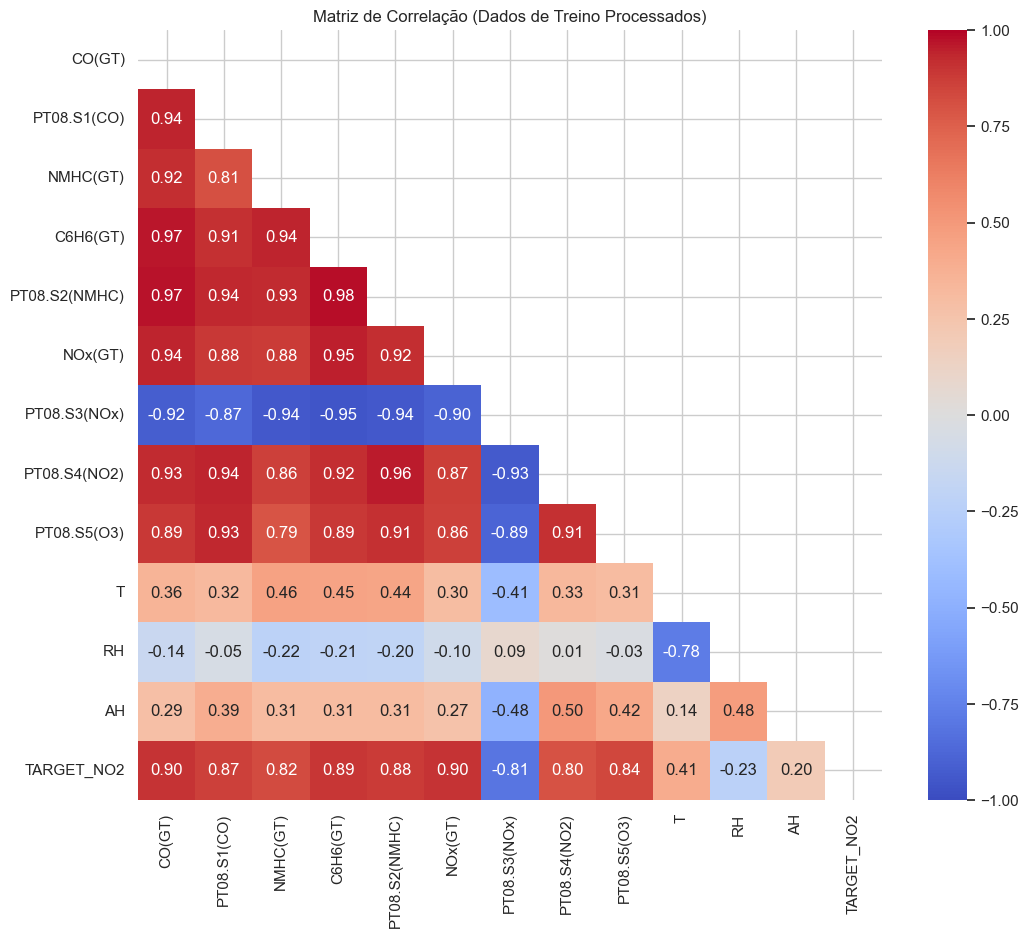

CO(GT)           0.904538
NOx(GT)          0.900596
C6H6(GT)         0.891888
PT08.S2(NMHC)    0.881931
PT08.S1(CO)      0.866645
PT08.S5(O3)      0.838444
NMHC(GT)         0.821965
PT08.S4(NO2)     0.803828
T                0.405686
AH               0.202118
RH              -0.230321
PT08.S3(NOx)    -0.810441
Name: TARGET_NO2, dtype: float64


In [10]:
# Heatmap de Correlação
train_full = X_train_norm.copy()
train_full['TARGET_NO2'] = y_train

plt.figure(figsize=(12, 10))
corr = train_full.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", mask=mask, vmin=-1, vmax=1)
plt.title("Matriz de Correlação (Dados de Treino Processados)")
plt.show()

# Correlações Top com Target
print(corr['TARGET_NO2'].drop('TARGET_NO2').sort_values(ascending=False))

### 5. Implementação de Regressão Linear (OLS)
#### Fórmula: $\beta = (X^T X)^{-1} X^T y$

In [11]:
class LinearRegressionOLS_Manual:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values     # Converte para numpy array se for DataFrame para álgebra matricial

        # Adiciona coluna de 1s para o intercepto (Bias)
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # Equação Normal: inv(X.T * X) * X.T * y
        try:
            theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(
                X_b.T).dot(y)  # Tenta inversa normal antes
        except np.linalg.LinAlgError:
            # Usa pseudo-inversa se a matriz for singular (determinante = 0)
            theta_best = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        self.intercept_ = theta_best[0]
        self.coef_ = theta_best[1:]

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return X.dot(self.coef_) + self.intercept_

print("Classe OLS Manual compilada com sucesso.")

Classe OLS Manual compilada com sucesso.


### 6. Comparação de modelos (Manual vs Scikit-Learn)
#### Treinamos nosso modelo manual e comparamos os resultados (RMSE e R²) com a implementação padrão do `sklearn`.

Comparação de Desempenho no Conjunto de Teste:


,Métrica,OLS Manual (From Scratch),OLS Sklearn (Built-in)
0,RMSE,10.403632,10.403632
1,R2 Score,0.896244,0.896244


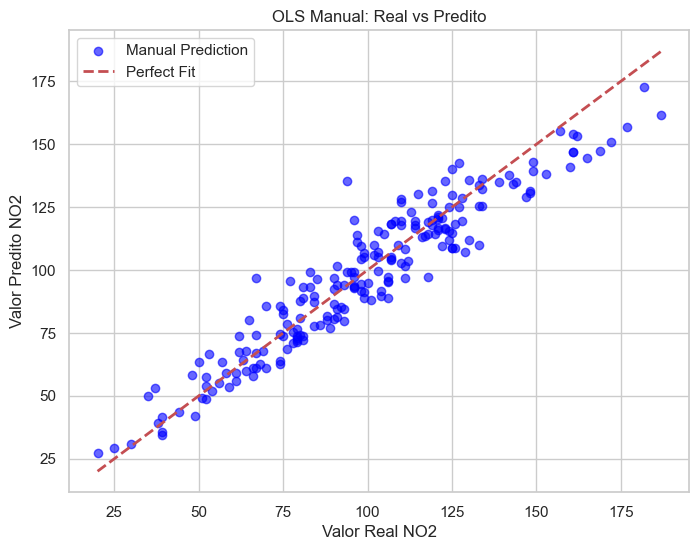

In [12]:
# Modelo Manual
ols_manual = LinearRegressionOLS_Manual()
ols_manual.fit(X_train_norm, y_train)
y_pred_manual = ols_manual.predict(X_test_norm)

# Modelo Scikit-Learn
ols_sklearn = LinearRegression()
ols_sklearn.fit(X_train_norm, y_train)
y_pred_sklearn = ols_sklearn.predict(X_test_norm)

# Função auxiliar de Métricas
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

rmse_man, r2_man = evaluate(y_test, y_pred_manual, "Manual")
rmse_skl, r2_skl = evaluate(y_test, y_pred_sklearn, "Sklearn")

# Tabela de Resultados
results_df = pd.DataFrame({
    "Métrica": ["RMSE", "R2 Score"],
    "OLS Manual (From Scratch)": [rmse_man, r2_man],
    "OLS Sklearn (Built-in)": [rmse_skl, r2_skl]
})

print("Comparação de Desempenho no Conjunto de Teste:")
display(results_df)

# Visualização Gráfica
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_manual, alpha=0.6,
            color='blue', label='Manual Prediction')
plt.plot([y_test.min(), y_test.max()], [y_test.min(),
         y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel("Valor Real NO2")
plt.ylabel("Valor Predito NO2")
plt.title("OLS Manual: Real vs Predito")
plt.legend()
savefig("ols_manual_vs_real")
plt.show()

### 7. Validação Cruzada (Cross-Validation)

### 7.1 Implementação manual da Cross-Validation
#### Implementamos manualmente o K-Fold CV. Criamos o loop que:
#### 1. Embaralha os dados.
#### 2. Divide em K partes.
#### 3. Itera K vezes, usando uma parte para teste e o resto para treino.

In [13]:
def k_fold_cv_manual(model_class, X, y, k=5):
    """Implementação manual de K-Fold Cross Validation."""
    # Garante arrays numpy
    X = X.values if isinstance(X, pd.DataFrame) else X
    y = y.values if isinstance(y, pd.Series) else y

    n_samples = len(X)
    fold_size = n_samples // k
    indices = np.arange(n_samples)
    np.random.shuffle(indices)  # Embaralhamento aleatório dos índices

    metrics = {"rmse": [], "r2": []}

    print(f"Executando {k}-Fold CV...")

    for i in range(k):
        start, end = i * fold_size, (i + 1) * fold_size
        val_idx = indices[start:end]  # Índices de Validação

        # Índices de Treino
        train_idx = np.concatenate([indices[:start], indices[end:]])

        # Criação das Folds
        X_f_train, y_f_train = X[train_idx], y[train_idx]
        X_f_val, y_f_val = X[val_idx], y[val_idx]

        # Treino e Predição
        model = model_class()
        model.fit(X_f_train, y_f_train)
        y_f_pred = model.predict(X_f_val)

        # Cálculo das Métricas
        rmse = np.sqrt(mean_squared_error(y_f_val, y_f_pred))
        r2 = r2_score(y_f_val, y_f_pred)

        metrics["rmse"].append(rmse)
        metrics["r2"].append(r2)

    return metrics

# Executa CV com 10 Folds usando a classe manual
# Usamos o X_train_norm pois CV é feito no treino para validar hiperparâmetros/estabilidade
cv_results = k_fold_cv_manual(
    LinearRegressionOLS_Manual, X_train_norm, y_train, k=10)

print("\nResultados Cross-Validation (10 Folds - Treino):")
print(
    f"RMSE Médio: {np.mean(cv_results['rmse']):.4f} (+/- {np.std(cv_results['rmse']):.4f})")
print(
    f"R2 Médio:   {np.mean(cv_results['r2']):.4f} (+/- {np.std(cv_results['r2']):.4f})")

Executando 10-Fold CV...

Resultados Cross-Validation (10 Folds - Treino):
RMSE Médio: 10.7482 (+/- 1.3681)
R2 Médio:   0.8759 (+/- 0.0351)


### 7.2 Perfil da Cross-Validation
#### O boxplot mostra a variação do erro (RMSE) ao longo dos folds.

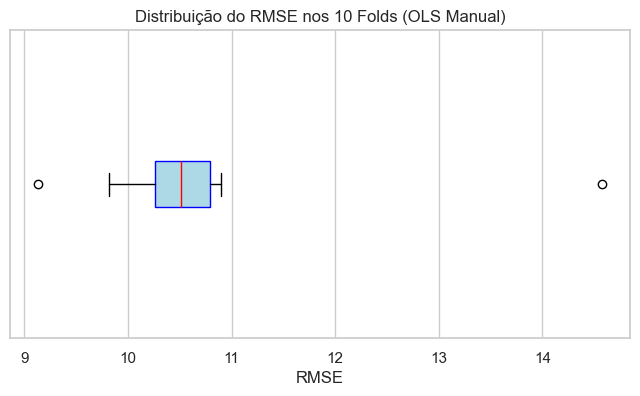

In [14]:
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results['rmse'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red"))
plt.title("Distribuição do RMSE nos 10 Folds (OLS Manual)")
plt.xlabel("RMSE")
plt.yticks([])
savefig("ols_cv_boxplot")
plt.show()